# Practical Application: Acoustic Noise Reduction in Motion-Compensated Diffusion

In advanced Diffusion MRI (like cardiac or liver diffusion), it is common to enforce **Motion-Compensated (M0, M1, M2 = 0)** gradient waveforms. However, forcing multi-moment nulling causes the gradient waveform to heavily oscillate. These fast oscillations frequently hit the **Mechanical Resonance Modes** of the scanner's gradient coil, creating extremely loud and sometimes unsafe acoustic vibrations.

In this notebook, we design a highly constrained **practical diffusion sequence** mimicking this scenario.
We will:
1. Generate a standardized motion-compensated waveform (the "Base Case") and observe the primary acoustic frequencies it excites.
2. Introduce the `Op_Acoustic` constraint to actively suppress specific "forbidden" scanner resonance bands that the base sequence inadvertently triggered.
3. Visually validate how the optimization negotiates between the hardware geometry, the zero-moments, and the B-value to completely squash the offending acoustic energy.

In [22]:
from timeit import default_timer as timer
import matplotlib.pyplot as plt
import numpy as np
import gropt

In [23]:
[asc_file, extra] = gropt.readasc.readasc(r'E:\MGH\Healthy_Grad\asc\CimaX.asc')
print(asc_file)
forbidden_frequency = gropt.readasc.asc_to_acoustic_resonances(asc_file)
print(forbidden_frequency)
[safe_params, safe_params_cardiac] = gropt.readasc.asc_to_safe(r'E:\MGH\Healthy_Grad\asc\CimaX.asc')
print(safe_params)

{'GradPatSup': {'GSWDStimulationSupervision': {0: {'sImpl': 'SAFEModel@GSWDModels', 'sName': 'PNS'}, 1: {'sImpl': 'SAFEModelCNS@GSWDModels', 'sName': 'CNS'}, 2: {'sImpl': '', 'sName': ''}}, 'Phys': {'PNS': {'flGSWDStimulationLimitX': 37.077, 'flGSWDStimulationLimitY': 22.988, 'flGSWDStimulationLimitZ': 32.209, 'flGSWDStimulationThresholdX': 29.661, 'flGSWDStimulationThresholdY': 18.391, 'flGSWDStimulationThresholdZ': 25.768, 'flGSWDTauX': {0: 0.6, 1: 12.0, 2: 0.2}, 'flGSWDTauY': {0: 0.889, 1: 12.0, 2: 0.193}, 'flGSWDTauZ': {0: 0.839, 1: 12.0, 2: 0.2}, 'flGSWDAX': {0: 0.412, 1: 0.2, 2: 0.388}, 'flGSWDAY': {0: 0.439, 1: 0.3, 2: 0.261}, 'flGSWDAZ': {0: 0.3, 1: 0.273, 2: 0.427}}, 'CarNS': {'flGSWDStimulationLimitX': 17.15, 'flGSWDStimulationLimitY': 17.38, 'flGSWDStimulationLimitZ': 15.78, 'flGSWDStimulationThresholdX': 0, 'flGSWDStimulationThresholdY': 0, 'flGSWDStimulationThresholdZ': 0, 'flGSWDAX': {0: 0.743, 1: 0.257, 2: 0}, 'flGSWDAY': {0: 0.743, 1: 0.257, 2: 0}, 'flGSWDAZ': {0: 0.743

### 1. Motion Compensated Diffusion Baseline
Let's enforce a gradient with max limits, an exact target `B-value = 500 s/mm^2`, and strict zero-moment conditions representing typical Flow/Vibration compensation ($M_0 = M_1 = M_2 = 0$).

In [29]:
gparams_base = gropt.GroptParams()

# Realistic scan timing parameters (Increased TE to 90ms to allow physical convergence without M2)
gparams_base.diff_init(dt=100e-6, TE=80e-3, T_90=3e-3, T_180=6e-3, T_readout=16e-3)
# gparams_base.diff_init_deadtime(dt=100e-6, TE=80e-3, T_90=3e-3, T_180=6e-3, T_readout=16e-3)

# Strict hardware limits
gparams_base.add_gmax(0.2)           # 200 mT/m max gradient amplitude
gparams_base.add_smax(200)           # 200 T/m/s max slew rate

# Multi-Moment nulling
gparams_base.add_moment(0, 0.0)      # M0 = 0 (Base position phase)
gparams_base.add_moment(1, 0.0)      # M1 = 0 (Velocity/Flow compensation)
gparams_base.add_moment(2, 0.0)      # M2 = 0 (Velocity/Flow compensation)
# Removed M2 = 0 as it prevents valid solutions at these short TEs and causes solver chatter

# Add Total Variation (TV) specifically to create a smooth base curve, minimizing noise
gparams_base.add_TV(1e-4, 10)
# gparams_base.add_obj_identity(1e-1)

# Target B-Value (500 s/mm^2)
gparams_base.add_bvalue(1000, 1)


print("Solving Base Oscillating Sequence...")
start_t = timer()
result_base = gropt.solve(gparams_base, max_iter=5000)
stop_t = timer()

out_base = result_base.X
print(f'Base Converged: {result_base.converged} | Solve time: {1000*(stop_t-start_t):.1f} ms')

Solving Base Oscillating Sequence...
Base Converged: False | Solve time: 247.0 ms


### 2. Targeting Scanner Resonance Overlaps
The oscillating gradients in the "Base Case" naturally end up dumping immense power spectral density into specific frequency bands. 
If a scanner's mechanical frame happens to have bending modes around **90 Hz** and **145 Hz**, this sequence will sound like a jackhammer.

We can deploy our new `Op_Acoustic` to define notch exclusion bands precisely where those scanner resonances lie, forcing the convex optimization to reroute the power to safer bands.

In [32]:
# The acoustic solver will use the exact same base setup
gparams_ac = gparams_base.clone()
# Let's inspect the baseline sequence and target the low frequency peak that naturally occurs!
forbidden_frequencies = [f['frequency'] for f in forbidden_frequency]
forbidden_bandwidths = [f['bandwidth'] for f in forbidden_frequency]

# Use a tapered band edge.
gparams_ac.add_acoustic(forbidden_frequencies, forbidden_bandwidths, weight_mod=10, bw_scale=0.4)

# gparams_base.add_SAFE(0.8, safe_params=safe_params)
gparams_base.add_SAFE(0.8, safe_params=safe_params_cardiac)

# Add TV over frequency domain
# gparams_ac.add_TV_Freq(tv_lam=1e-4, weight_mod=5.0, n_pad=4096)

# Add TV over Slew Rate (2nd order TV)
# gparams_ac.add_TV2(tv2_lam=1e-3, weight_mod=5.0)

print("Solving Acoustic Notched Sequence...")
start_t = timer()
result_ac = gropt.solve(gparams_ac, max_iter=25000)
stop_t = timer()

out_ac = result_ac.X
print(f'Acoustic Notched Converged: {result_ac.converged} | Solve time: {1000*(stop_t-start_t):.1f} ms')

Solving Acoustic Notched Sequence...
Acoustic Notched Converged: False | Solve time: 28391.3 ms


### 3. Visual Validation
Notice how in the Time Domain the solver has discovered a completely different, slightly wider "stretching" path that successfully yields `b=500` without tripping any `smax` or $M_n=0$ bounds. And in the Frequency Domain PSD, the offending spikes originally sitting at 90Hz and 145Hz have been successfully squeezed identically to $0.0$.

Max SAFE 1.064
Max SAFE Cardiac 1.058
Max SAFE Acoustic Notched 0.695
Max SAFE Cardiac Acoustic Notched 0.793
b-value Base 1000.006
b-value Acoustic Notched 1000.000


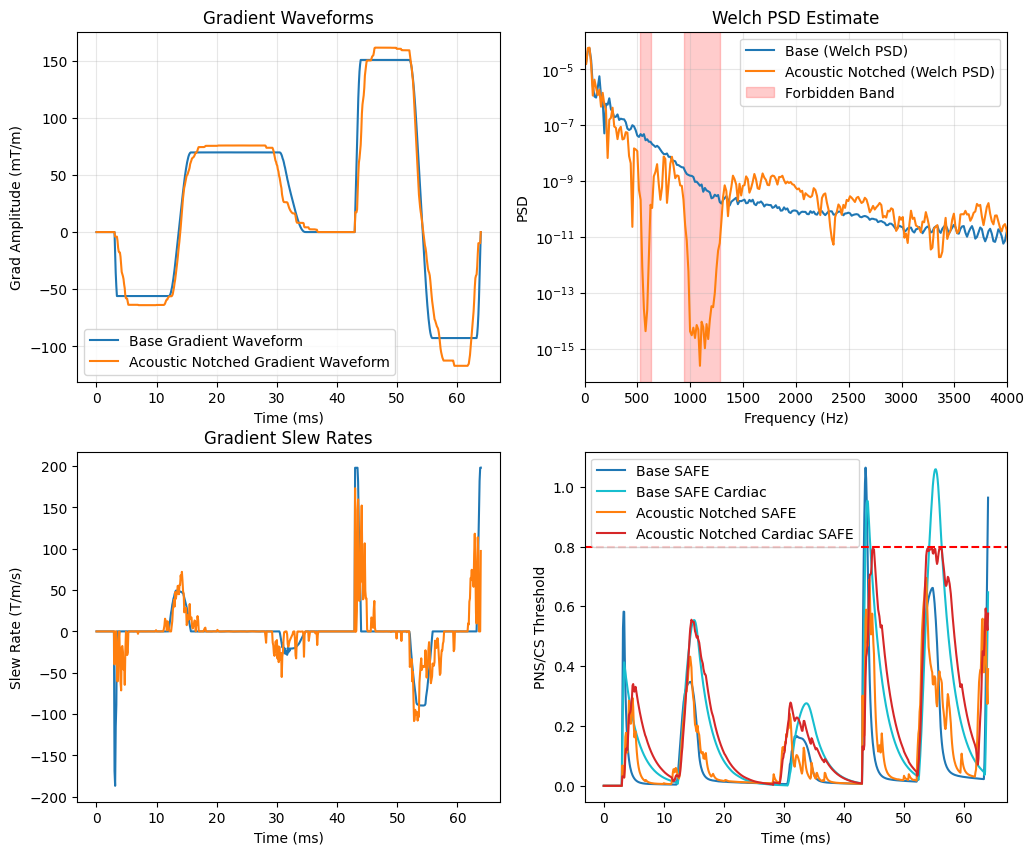

<Figure size 640x480 with 0 Axes>

In [34]:
from scipy.signal import welch

# Welch PSD estimation
fs = 1.0 / gparams_base.dt
nperseg = min(2048, out_base.size)
noverlap = nperseg // 2

xf, psd_base = welch(out_base, fs=fs, window="hann", nperseg=nperseg, noverlap=noverlap, scaling="density")
_, psd_ac = welch(out_ac, fs=fs, window="hann", nperseg=nperseg, noverlap=noverlap, scaling="density")

tt_ms = np.arange(out_base.size) * gparams_base.dt * 1e3

new_first_axis = 0
safe_base = gropt.gropt_wrapper.get_SAFE(out_base, gparams_base.dt, 
                                    new_first_axis=new_first_axis, 
                                    safe_params=safe_params)
safe_cardiac_base = gropt.gropt_wrapper.get_SAFE(out_base, gparams_base.dt, 
                                    new_first_axis=new_first_axis, 
                                    safe_params=safe_params_cardiac)
safe_ac = gropt.gropt_wrapper.get_SAFE(out_ac, gparams_base.dt,
                                    new_first_axis=new_first_axis,
                                    safe_params=safe_params)
safe_cardiac_ac = gropt.gropt_wrapper.get_SAFE(out_ac, gparams_base.dt,
                                    new_first_axis=new_first_axis,
                                    safe_params=safe_params_cardiac)
# Calculate b-value
bvalue_base = result_base.bvalue
bvalue_ac = result_ac.bvalue

print(f'Max SAFE {np.max(safe_base):.3f}')
print(f'Max SAFE Cardiac {np.max(safe_cardiac_base):.3f}')
print(f'Max SAFE Acoustic Notched {np.max(safe_ac):.3f}')
print(f'Max SAFE Cardiac Acoustic Notched {np.max(safe_cardiac_ac):.3f}')
print(f'b-value Base {bvalue_base:.3f}')
print(f'b-value Acoustic Notched {bvalue_ac:.3f}')

# Optional comparison plot
plt.figure(figsize=(12, 10))
plt.subplot(221)
plt.plot(tt_ms, out_base*1000, label="Base Gradient Waveform", color="tab:blue")
plt.plot(tt_ms, out_ac*1000, label="Acoustic Notched Gradient Waveform", color="tab:orange")
plt.xlabel("Time (ms)")
plt.ylabel("Grad Amplitude (mT/m)")
plt.title("Gradient Waveforms")
plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.subplot(222)
plt.semilogy(xf, psd_base, label="Base (Welch PSD)", color="tab:blue")
plt.semilogy(xf, psd_ac, label="Acoustic Notched (Welch PSD)", color="tab:orange")
for idx, (f, bw) in enumerate(zip(forbidden_frequencies, forbidden_bandwidths)):
    plt.axvspan(f - bw / 2, f + bw / 2, alpha=0.2, color="red", label="Forbidden Band" if idx == 0 else None)
plt.xlim(0, 4000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Welch PSD Estimate")
plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.subplot(223)
plt.plot(tt_ms[:-1], np.diff(out_base)/gparams_base.dt, label="Base Gradient Slew Rate", color="tab:blue")
plt.plot(tt_ms[:-1], np.diff(out_ac)/gparams_base.dt, label="Acoustic Notched Gradient Slew Rate", color="tab:orange")
plt.xlabel("Time (ms)")
plt.ylabel("Slew Rate (T/m/s)")
plt.title("Gradient Slew Rates")

plt.subplot(224)
plt.plot(tt_ms, safe_base, label="Base SAFE", color="tab:blue")
plt.plot(tt_ms, safe_cardiac_base, label="Base SAFE Cardiac", color="tab:cyan")
plt.plot(tt_ms, safe_ac, label="Acoustic Notched SAFE", color="tab:orange")
plt.plot(tt_ms, safe_cardiac_ac, label="Acoustic Notched Cardiac SAFE", color="tab:red")
plt.legend()

plt.axhline(0.8, color="red", linestyle="--", label="SAFE Limit")
plt.xlabel("Time (ms)")
plt.ylabel("PNS/CS Threshold")
plt.show()

plt.tight_layout()